# Learn image representations with I-JEPA

The earlier notebooks trained models that produce something, an image or some text. This one is a bit different: it trains an encoder whose only product is a vector for each image, and the goal is that similar images get similar vectors. Why would we want that? Well, if the vectors are good, even a very simple classifier, or just looking up an image's nearest neighbours, can tell the images apart, and that is exactly how we will test ours below.

We use I-JEPA, from the paper ["Self-Supervised Learning from Images with a Joint-Embedding Predictive Architecture" by Assran et al. (2023)](https://arxiv.org/abs/2301.08243). The encoder sees part of an image and has to predict the encoder's own embeddings of the hidden parts. It never reconstructs pixels, and it needs no hand-made augmentations such as crops and colour jitter.

After training, we check the vectors in three ways: a linear probe and a k-nearest-neighbour probe that try to read the flower species out of them, and a look at each query image's nearest neighbours.

**The notebook expects one NVIDIA GPU.**

## Install Dependencies

Dew from GitHub with three extras: `cuda13` for the GPU, `streaming` for Hugging Face `datasets`, and `interop` for the safetensors file we save the encoder to at the end.

In [ ]:
%pip install -q "dew-ml[cuda13,streaming,interop] @ git+https://github.com/AshishKumar4/dew"

## Settings

The images are 64x64 and the encoder cuts them into 8x8 patches, which gives an 8 by 8 grid of 64 tokens. `NUM_TARGET_BLOCKS` and `BLOCK_SCALE` set the hidden regions: four blocks, each covering 15 to 20% of the image. The flower labels run from 1 to 102, so the probes use 103 classes.

In [1]:
import os

IMAGE_SIZE = 64
PATCH_SIZE = 8
GRID = (IMAGE_SIZE // PATCH_SIZE, IMAGE_SIZE // PATCH_SIZE)
BATCH_SIZE = 128
STEPS = 4000
LEARNING_RATE = 5e-4
EMB_FEATURES = 192
NUM_LAYERS = 6
NUM_HEADS = 3
NUM_TARGET_BLOCKS = 4
BLOCK_SCALE = (0.15, 0.2)
CLASSES = 103
DATA_FILE = "data/06-flowers.parquet"
RUN_DIR = "runs/06-jepa"
SEED = 0

# The tutorial test sets DEW_TUTORIAL_SMOKE=1 to run every cell in minutes on a CPU.
if os.environ.get("DEW_TUTORIAL_SMOKE") == "1":
    BATCH_SIZE, STEPS = 16, 4


In [2]:
from pathlib import Path

import jax
import matplotlib.pyplot as plt
import numpy as np

print(jax.devices())

[CudaDevice(id=0)]


## Data Pipeline

We use the Hugging Face copy of Oxford Flowers again, this time for its species labels. But there is a catch: that copy is sorted by species, and Dew holds out the validation images from the head of the dataset, so the held-out set would be only two or three species. So we shuffle the dataset once and save a local Parquet copy, and `HFImages` reads it through the `parquet` loader of `datasets`.

`augmentation="none"` turns off the random flips, because in I-JEPA the variation comes from the masks. `val_batches=8` holds out the first 1,024 shuffled images. The encoder never trains on them, and the probes score only them.

In [3]:
import datasets

Path(DATA_FILE).parent.mkdir(parents=True, exist_ok=True)
flowers = datasets.load_dataset("pranked03/flowers-blip-captions", split="train")
flowers.shuffle(seed=SEED).to_parquet(DATA_FILE)
print(flowers)

/content/batch/job-1/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Creating parquet from Arrow format:   0%|          | 0/3 [00:00<?, ?ba/s]

Creating parquet from Arrow format:  33%|███▎      | 1/3 [00:00<00:00,  4.25ba/s]

Creating parquet from Arrow format:  67%|██████▋   | 2/3 [00:00<00:00,  4.26ba/s]

Creating parquet from Arrow format: 100%|██████████| 3/3 [00:00<00:00,  4.77ba/s]

Creating parquet from Arrow format: 100%|██████████| 3/3 [00:00<00:00,  4.61ba/s]

Dataset({
    features: ['image', 'label', 'text'],
    num_rows: 6552
})


In [4]:
from dew.data import DataPartition, HFImages, HFOptions, Loading

data = HFImages(
    name="parquet",
    options=HFOptions(data_files=DATA_FILE),
    image_size=IMAGE_SIZE,
    augmentation="none",
    val_batches=8,
    loading=Loading(workers=0, threads=16, read_buffer=64),
).load(batch=BATCH_SIZE)

val_labels = np.concatenate([batch["label"] for batch in data.val(DataPartition())])
print("training images:", data.records, "| held-out images:", len(val_labels),
      "| species in the held-out set:", len(np.unique(val_labels)))

Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 2360 examples [00:00, 7141.45 examples/s]

Generating train split: 4720 examples [00:00, 11767.13 examples/s]

Generating train split: 6552 examples [00:00, 13160.82 examples/s]

training images: 5528 | held-out images: 1024 | species in the held-out set: 102


## The mask

Each training image gets `NUM_TARGET_BLOCKS` rectangles of patches to predict, with a random size and aspect ratio, and the context the encoder sees is a random subset of the remaining patches. `multi_block_mask` works out the block sizes once for the grid, so every mask has the same number of tokens and the training step compiles only once.

Below is one sampled mask: `.` is context the encoder sees, `#` is a patch it has to predict, and `-` is dropped.

In [5]:
from dew.objectives.jepa import multi_block_mask

mask = multi_block_mask(GRID, num_targets=NUM_TARGET_BLOCKS, scale=BLOCK_SCALE)
print("context tokens:", mask.num_context, "| target blocks:", mask.num_targets,
      "of", mask.block_area, "tokens each")

context_idx, target_idx = mask.sample(jax.random.key(SEED), 1)
view = np.full(GRID[0] * GRID[1], "-")
view[np.asarray(context_idx[0])] = "."
view[np.asarray(target_idx).reshape(-1)] = "#"
print("\n".join(" ".join(row) for row in view.reshape(GRID)))

context tokens: 16 | target blocks: 4 of 12 tokens each


# # # # # # - .
# # # # # # - -
# # # # # # . -
# # # # # # . .
# # # # # - - .
. . # # # - - .
. - . - . - . -
. . - - . . - -


## Encoder, predictor and objective

I-JEPA has three networks:

- **the context encoder**, a ViT that sees only the context patches;
- **the target encoder**, which sees the whole image and produces the embeddings to predict;
- **the predictor**, a narrower transformer that takes the context embeddings plus the positions of the hidden patches and guesses the target encoder's embeddings there.

The target encoder is not trained. It is an exponential moving average of the context encoder, so the targets improve as the encoder improves. `JepaObjective` puts the three together and asks the trainer to keep that average, whose momentum grows from 0.996 to 1 over `momentum_steps`.

The loss is the squared distance between the predicted and the target embeddings. *But couldn't the encoder cheat, and give every image the same vector, so that every prediction is trivially right?* It could, and this failure is called collapse. So the objective also reports `repr_std`, the spread of the embeddings across a batch. If it falls towards zero, the encoder is giving every image the same vector.

In [6]:
from dew import Field, models
from dew.objectives.jepa import JepaObjective

encoder = models.build("jepa_encoder", patch_size=PATCH_SIZE, emb_features=EMB_FEATURES,
                       num_layers=NUM_LAYERS, num_heads=NUM_HEADS,
                       dtype="bfloat16", attention_impl="auto")
predictor = models.build("jepa_predictor", grid=GRID, emb_features=EMB_FEATURES,
                         predictor_features=EMB_FEATURES // 2, num_layers=NUM_LAYERS // 2,
                         num_heads=NUM_HEADS, dtype="bfloat16", attention_impl="auto")
objective = JepaObjective(encoder, predictor, mask=mask,
                          sample=Field("image", (IMAGE_SIZE, IMAGE_SIZE, 3)),
                          momentum_steps=STEPS)

variables = jax.eval_shape(objective.init, jax.random.key(0))
for name, tree in variables["params"].items():
    print(f"{name}: {sum(x.size for x in jax.tree_util.tree_leaves(tree)) / 1e6:.2f}M parameters")

context_encoder: 2.71M parameters
predictor: 0.37M parameters


## Training

Same as before: `fit` trains, logs every 500 steps and writes the checkpoint at the end. Then we plot both the loss and `repr_std`, to make sure the encoder hasn't collapsed.

In [7]:
import optax
from dew import Checkpoints, LocalTracker, Trainer

trainer = Trainer(objective, optax.adamw(LEARNING_RATE), key=jax.random.key(SEED),
                  checkpoints=Checkpoints(RUN_DIR), tracker=LocalTracker(f"{RUN_DIR}/tracking"))
state = trainer.fit(data, steps=STEPS, log_every=500, checkpoint_every=STEPS)

Training from step 0 to 4000 on {'data': 1, 'expert': 1, 'fsdp': 1, 'tensor': 1, 'sequence': 1, 'stage': 1} (1 process(es))


step 500: loss 0.0762


step 1000: loss 0.1237


step 1500: loss 0.1323


step 2000: loss 0.1495


step 2500: loss 0.1497


step 3000: loss 0.1561


step 3500: loss 0.1420


step 4000: loss 0.1882


Goodput: first step after 58.46 s, 92.3% of the wall time in steps


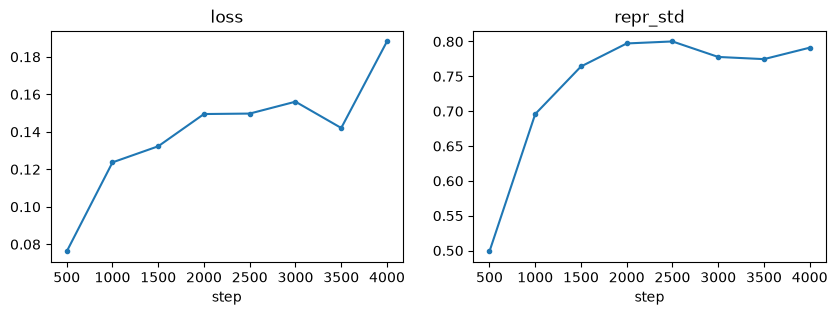

In [8]:
import json

rows = [json.loads(line) for line in open(f"{RUN_DIR}/tracking/scalars.jsonl")]
rows = [row for row in rows if "train/loss" in row["scalars"]]
steps = [row["step"] for row in rows]
figure, (left, right) = plt.subplots(1, 2, figsize=(10, 3))
left.plot(steps, [row["scalars"]["train/loss"] for row in rows], marker=".")
left.set(xlabel="step", title="loss")
right.plot(steps, [row["scalars"]["train/repr_std"] for row in rows], marker=".")
right.set(xlabel="step", title="repr_std")
plt.show()

## Probes on the held-out images

`objective.evaluate` embeds a batch with the target encoder (the EMA weights) and averages each image's patch embeddings into one vector. We collect those vectors for all 1,024 held-out images.

Each probe fits on half of the vectors and scores the other half. The linear probe is logistic regression; the k-NN probe gives each image the majority species of its 20 nearest neighbours. Now, both scores mean little on their own, because a probe with more dimensions than images can fit almost anything. So we also run both probes with the labels shuffled. The gap between the real and the shuffled score is how much species information the vectors actually carry. For reference, chance on 102 species is about 1%.

In [9]:
from dew.objectives.base import Step
from dew.objectives.jepa import representation_health
from dew.objectives.jepa.probes import knn_probe_accuracy, linear_probe_accuracy

features, labels, held_out = [], [], []
for batch in data.val(DataPartition()):
    scored = objective.evaluate(state.params, batch,
                                Step(step=state.step, key=jax.random.key(1), ema=state.averaged))
    features.append(np.asarray(scored.features))
    labels.append(np.asarray(scored.labels))
    held_out.append(batch["image"])
features, labels, held_out = np.concatenate(features), np.concatenate(labels), np.concatenate(held_out)
print("held-out embeddings:", features.shape)

health = representation_health(features)
print(f"repr_std {float(health['repr_std']):.3f} | repr_cov_offdiag {float(health['repr_cov_offdiag']):.4f}")

shuffled = np.random.default_rng(0).permutation(labels)
for name, probe in (("linear probe", linear_probe_accuracy), ("k-NN probe", knn_probe_accuracy)):
    real = float(probe(features, labels, CLASSES))
    control = float(probe(features, shuffled, CLASSES))
    print(f"{name}: {real:.3f} with the real labels, {control:.3f} with shuffled labels")

held-out embeddings: (1024, 192)


repr_std 0.801 | repr_cov_offdiag 0.3725


linear probe: 0.271 with the real labels, 0.012 with shuffled labels


k-NN probe: 0.148 with the real labels, 0.010 with shuffled labels


## Nearest neighbours

The probes give one number each, but we can also look at the vectors directly. Each row below is one held-out query image (left) and its five nearest held-out images by cosine similarity, with their species labels.

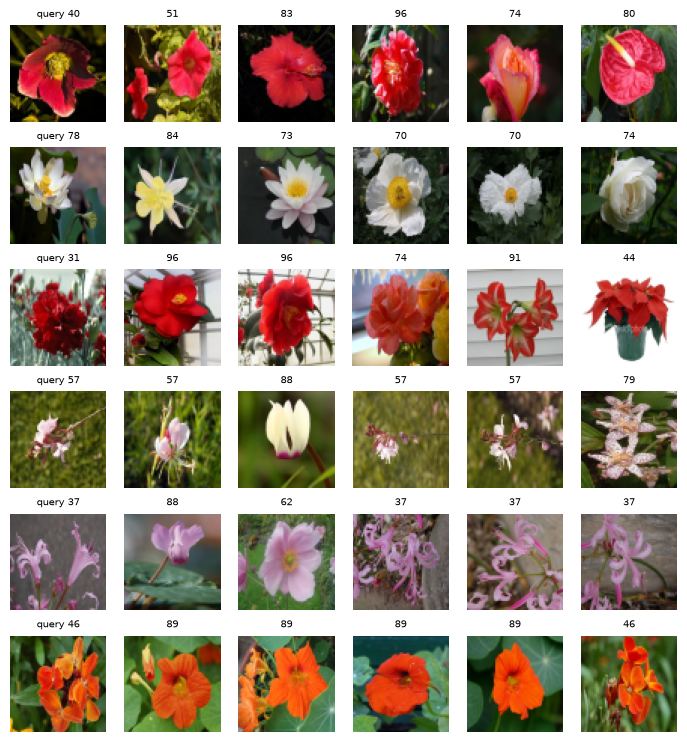

In [10]:
normalised = features / np.linalg.norm(features, axis=-1, keepdims=True)
queries = [0, 1, 2, 3, 4, 5]
figure, axes = plt.subplots(len(queries), 6, figsize=(7, len(queries) * 1.25))
for row, query in enumerate(queries):
    neighbours = np.argsort(-(normalised @ normalised[query]))[1:6]
    for column, index in enumerate([query, *neighbours]):
        axis = axes[row, column]
        axis.imshow(held_out[index])
        axis.set_title(f"{'query ' if column == 0 else ''}{labels[index]}", fontsize=7)
        axis.axis("off")
plt.tight_layout()
plt.show()

## Keeping the encoder

What we keep from a JEPA run is the EMA copy of the context encoder, without the predictor. `save_params` writes it as a safetensors file, and `load_params` reads it back. `objective.encode` embeds images in `[-1, 1]` with a given set of encoder weights.

In [11]:
from dew.interop import load_params, save_params

encoder_params = state.averaged["params"]["context_encoder"]
save_params(encoder_params, f"{RUN_DIR}/encoder.safetensors")
reloaded = load_params(f"{RUN_DIR}/encoder.safetensors")
again = objective.encode(reloaded, held_out[:8].astype(np.float32) / 127.5 - 1)
print("reloaded encoder output:", np.asarray(again).shape)

reloaded encoder output: (8, 64, 192)


## Where to go next

The I-JEPA paper trains a ViT-H/16 for 300 epochs on ImageNet; the knobs to scale up are the ones in the settings cell. `recipes/jepa/train.py` runs the same objective from the command line, and the `jepa_video_encoder` model with a factorized predictor does the same job on video clips.